In [1]:
import xgboost
from sklearn.model_selection import train_test_split

In [9]:
import pandas as pd
DF = pd.read_parquet("processed_data/HI-Small_Trans_TRAIN_processed.parquet")

In [10]:
DF.columns

Index(['Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering', 'TS_Year',
       'TS_Month', 'TS_Day', 'TS_WeekDay', 'TS_Hour', 'TS_Minute',
       'TS_Timestamp', 'Same_Currency', 'FROM', 'TO', 'Same_Bank'],
      dtype='object')

In [36]:
X_train, X_test, y_train, y_test = train_test_split(DF.loc[:, [col for col in DF.columns if col not in ['Is Laundering', 'FROM', 'TO']]], DF['Is Laundering'], test_size=0.3)

In [37]:
model = xgboost.XGBRFClassifier()

In [38]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.linear_model import LogisticRegression

In [39]:
model = xgboost.XGBClassifier()
model.fit(X_train, y_train)
# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
confusion_matrix(y_true=y_test,y_pred=y_pred)

Accuracy: 0.9991516266369544
Recall: 0.001936108422071636


array([[1217767,       3],
       [   1031,       2]])

In [40]:
importance_scores = model.get_booster().get_score(importance_type='gain')

In [41]:
importance_scores

{'Amount Received': 21.054157257080078,
 'Receiving Currency': 20.726274490356445,
 'Amount Paid': 4.921854496002197,
 'Payment Currency': 9.392868995666504,
 'Payment Format': 66.50483703613281,
 'TS_Day': 68.80353546142578,
 'TS_WeekDay': 3.554556369781494,
 'TS_Hour': 2.8942394256591797,
 'TS_Minute': 2.5691492557525635,
 'TS_Timestamp': 12.646220207214355,
 'Same_Currency': 4.361307621002197,
 'Same_Bank': 89.46832275390625}

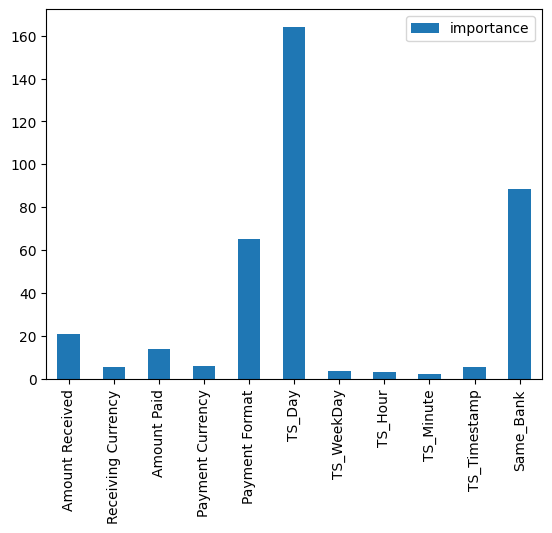

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame
importance_df = pd.DataFrame.from_dict(data=importance_scores, orient='index', columns=['importance'])

# Plot the importance scores
importance_df.plot.bar()
plt.show()